In [1]:
import torch
import sys

sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is not available


In [2]:
from main import load_and_process_config
from dataset import from_config
from utilities import tensor_dict_summarize

config = load_and_process_config("../config_train.yaml")
dataset = from_config(config)["training"]

DATASET  [12:46:34] Processing 7 datasets: ['SCRREAM', 'HOUSECAT6D', 'CROMO', 'PSD', 'SCARED', 
'STEREOMIS_TRACKING', 'CHOLEC80']

DATASET  [12:46:34] Using all scenes except VAL_SCENES for SCRREAM training

DATASET  [12:46:34]   ✓ Created training dataset for SCRREAM: 1492 samples (excluding 2 val scenes)

DATASET  [12:46:34]   ✓ Created validation dataset for SCRREAM: 167 samples from 2 scenes

DATASET  [12:46:34] Using all scenes except VAL_SCENES for HOUSECAT6D training

...

DATASET  [12:46:34]   ✓ Created validation dataset for CHOLEC80: 461 samples from 1 scenes

DATASET  [12:46:34] === Dataset Creation Summary ===

DATASET  [12:46:34] Training:   9161 total samples

DATASET  [12:46:34] Validation: 2270 total samples

DATASET  [12:46:34] Test:       2270 total samples

raw: shape=(1, 3, 896, 896), device=cpu

specular: shape=(1, 3, 896, 896), device=cpu

diffuse: shape=(1, 3, 896, 896), device=cpu

intrinsics: shape=(1, 3, 3), device=cpu

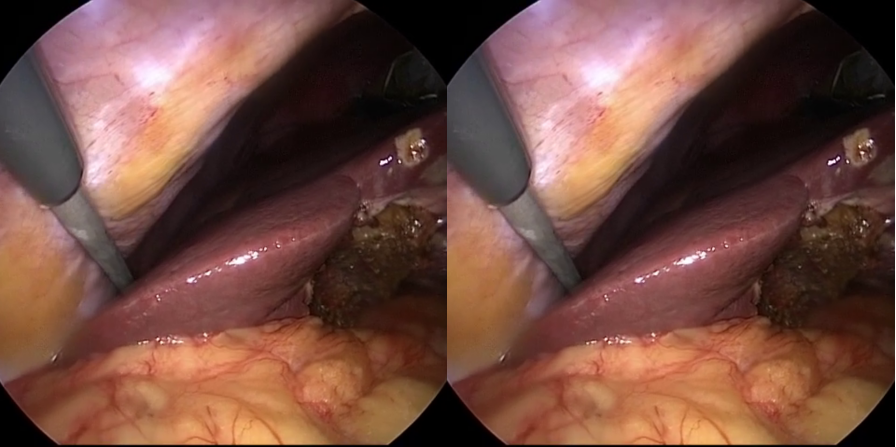

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
# highlighter = PolarHighlighter(width=448, height=448).cuda()

for batch in dataloader:
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }
    tensor_dict_summarize(batch)
    # highlighted = highlighter(
    #     batch["diffuse"],
    #     noise=0.03,
    #     noise_type=config.NOISE_TYPE,
    #     noise_octaves=config.NOISE_OCTAVES,
    #     noise_persistence=config.NOISE_PERSISTENCE,
    #     surface_roughness=config.SURFACE_ROUGHNESS,
    #     intensity=config.INTENSITY,
    # )
    rgb(
        panelize(
            rgb(batch["raw"], as_tensor=True,),
            rgb(batch["diffuse"], as_tensor=True,),
            # rgb(highlighted["rgb_highlighted"], as_tensor=True, resize=(448, 448)),
        )
    )
    break


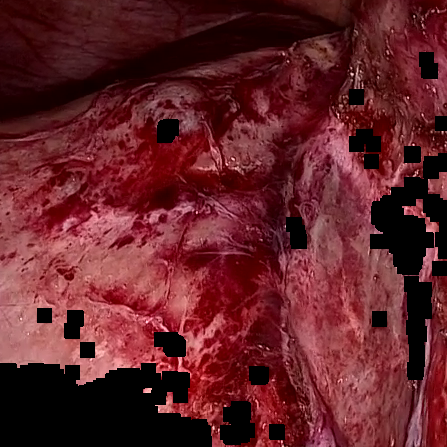

In [8]:
from polar_highlighter import get_soft_highlight_map
real_highlight_soft_mask = get_soft_highlight_map(
    batch["diffuse"].to("cuda", non_blocking=True),
    threshold=config.SOFT_HIGHLIGHT_THRESHOLD,
)
# Compute inverse binary mask to mask out real highlights from the loss computation
real_highlight_inverse_binary_mask = torch.logical_not(
    torch.nn.functional.max_pool2d(
        real_highlight_soft_mask,
        kernel_size=config.REAL_HIGHLIGHT_DILATION,
        stride=1,
        padding=config.REAL_HIGHLIGHT_DILATION // 2,
    )
    > 0
).int()
rgb(real_highlight_inverse_binary_mask*batch["diffuse"])

In [12]:
real_highlight_inverse_binary_mask.shape

torch.Size([1, 1, 448, 448])

In [13]:
from loss_utils import hole_and_ring_masks
hole_mask, ring_mask = hole_and_ring_masks(real_highlight_inverse_binary_mask,21)

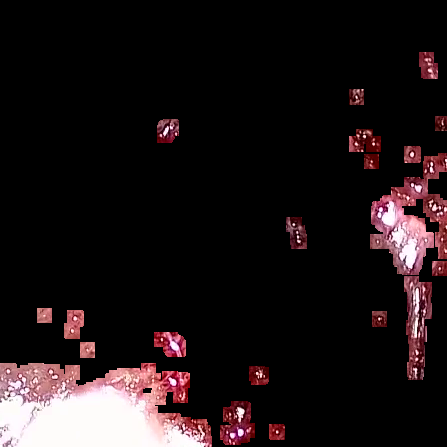

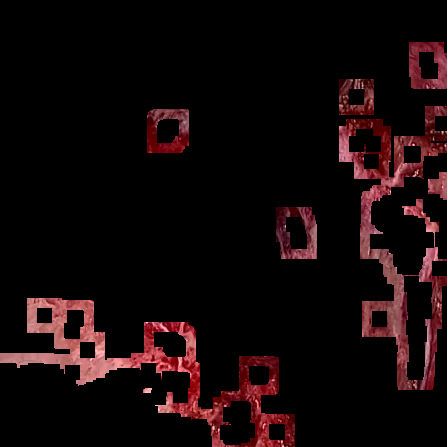

In [15]:
rgb(hole_mask*batch["diffuse"])
rgb(ring_mask*batch["diffuse"])